# BQIS - Biscuit Quality Intelligence System
### Pipeline: EDA -> Preprocessing -> Modeling -> Evaluation

**Case:** Data Analysis - SPL Biscuit Quality Testing (TUV NORD Indonesia)
**Penanggung jawab teknis:** Lala

Dataset sintetis 1000 baris, threshold mengacu pada SNI 2973:2022 - Biskuit.


## 0. Import Library & Load Data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, RocCurveDisplay)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


In [12]:
df = pd.read_csv("D:\\BQIS\\data\\bqis_biscuit_quality_dataset.csv")
df.head()


,Sample_ID,Batch_Code,Product_Name,Test_Date,Moisture_Content_%,Fat_Content_%,Protein_Content_%,Water_Activity_Aw,Acid_Insoluble_Ash_%,Acid_Value_mgKOHg,Peroxide_Value,Total_Plate_Count_CFUg,Yeast_Mold_Count_CFUg,Lead_Pb_mgkg,Cadmium_Cd_mgkg,Failure_Category,Historical_Status
0,SPL-2026-0409,B-250101-4,Wafer Vanilla,2025-01-01,3.23,19.10,9.95,0.543,0.058,1.61,1.34,5670,2232,0.045,0.098,NaN,Pass
1,SPL-2026-0949,B-250101-5,Wafer Vanilla,2025-01-01,1.23,17.81,4.76,0.375,0.045,1.13,1.05,5847,272,0.014,0.018,NaN,Pass
2,SPL-2026-0482,B-250101-7,Cookies Choco Chip,2025-01-01,3.69,16.93,NaN,0.620,0.058,0.68,1.07,27579,162,0.363,0.162,NaN,Pass
3,SPL-2026-0488,B-250101-1,Cracker Plain,2025-01-01,2.69,11.10,7.07,0.505,0.071,1.69,1.27,1447,99,0.015,0.001,NaN,Pass
4,SPL-2026-0996,B-250102-6,Cracker Filled,2025-01-02,3.69,26.64,7.41,0.557,0.015,1.89,1.80,780,1397,0.509,0.039,Heavy_Metal,Fail


## 1. First Look at the Data

Tujuan: kenalan sama struktur data sebelum diapa-apain — jumlah baris, tipe kolom,
dan gambaran statistik dasar.

In [13]:
print("Shape:", df.shape)
df.info()


Shape: (1000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sample_ID               1000 non-null   object 
 1   Batch_Code              1000 non-null   object 
 2   Product_Name            1000 non-null   object 
 3   Test_Date               1000 non-null   object 
 4   Moisture_Content_%      960 non-null    float64
 5   Fat_Content_%           950 non-null    float64
 6   Protein_Content_%       950 non-null    float64
 7   Water_Activity_Aw       940 non-null    float64
 8   Acid_Insoluble_Ash_%    930 non-null    float64
 9   Acid_Value_mgKOHg       940 non-null    float64
 10  Peroxide_Value          920 non-null    float64
 11  Total_Plate_Count_CFUg  1000 non-null   int64  
 12  Yeast_Mold_Count_CFUg   1000 non-null   int64  
 13  Lead_Pb_mgkg            970 non-null    float64
 14  Cadmium_Cd_mgkg        

In [14]:
df.describe()


,Moisture_Content_%,Fat_Content_%,Protein_Content_%,Water_Activity_Aw,Acid_Insoluble_Ash_%,Acid_Value_mgKOHg,Peroxide_Value,Total_Plate_Count_CFUg,Yeast_Mold_Count_CFUg,Lead_Pb_mgkg,Cadmium_Cd_mgkg
count,960.000000,950.000000,950.000000,940.000000,930.000000,940.000000,920.000000,1000.000000,1000.00000,970.000000,970.000000
mean,3.507271,17.998832,6.501232,0.568088,0.044427,1.006372,0.996446,6887.065000,1468.82300,0.143897,0.060341
std,1.016578,3.452869,1.591453,0.095088,0.045201,0.526366,0.445746,14625.977362,2984.68515,0.144154,0.060078
min,0.540000,8.810000,2.500000,0.244000,0.001000,0.050000,0.050000,30.000000,14.00000,0.001000,0.001000
25%,2.837500,15.572500,5.400000,0.505750,0.012000,0.650000,0.680000,998.750000,288.00000,0.041250,0.016000
50%,3.570000,17.895000,6.510000,0.570000,0.029000,0.965000,0.980000,2483.000000,645.00000,0.098000,0.041000
75%,4.180000,20.135000,7.617500,0.635000,0.062750,1.360000,1.310000,6765.000000,1359.25000,0.200750,0.085000
max,6.510000,30.090000,11.690000,0.850000,0.317000,2.820000,2.650000,258279.000000,48508.00000,1.200000,0.344000


## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Balance
Cek proporsi Pass vs Fail. Kalau imbalance-nya ekstrim (misal 95:5), perlu teknik
resampling khusus (SMOTE, class_weight). Kalau ringan, XGBoost masih aman dipakai
langsung.

Historical_Status
Pass    652
Fail    348
Name: count, dtype: int64
Historical_Status
Pass    65.2
Fail    34.8
Name: count, dtype: float64 %


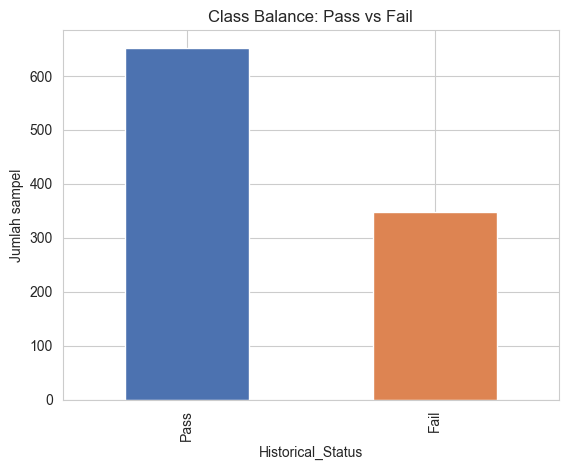

In [15]:
status_counts = df['Historical_Status'].value_counts()
print(status_counts)
print((status_counts / len(df) * 100).round(1), "%")

status_counts.plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title("Class Balance: Pass vs Fail")
plt.ylabel("Jumlah sampel")
plt.show()


### 2.2 Missing Value Map
Cek kolom mana yang punya missing value dan seberapa besar persentasenya.
Rule yang dipakai (sesuai executive summary BQIS): sampel dengan >30% parameter
kosong dikeluarkan dari analisis AI dan di-flag untuk manual review.

Failure_Category        65.2
Peroxide_Value           8.0
Acid_Insoluble_Ash_%     7.0
Water_Activity_Aw        6.0
Acid_Value_mgKOHg        6.0
Fat_Content_%            5.0
Protein_Content_%        5.0
Moisture_Content_%       4.0
Lead_Pb_mgkg             3.0
Cadmium_Cd_mgkg          3.0
dtype: float64


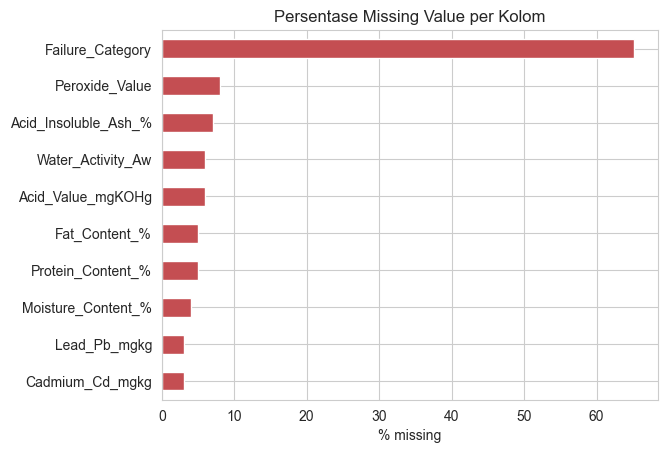

In [16]:
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(missing_pct)

missing_pct.plot(kind='barh', color='#C44E52')
plt.title("Persentase Missing Value per Kolom")
plt.xlabel("% missing")
plt.gca().invert_yaxis()
plt.show()


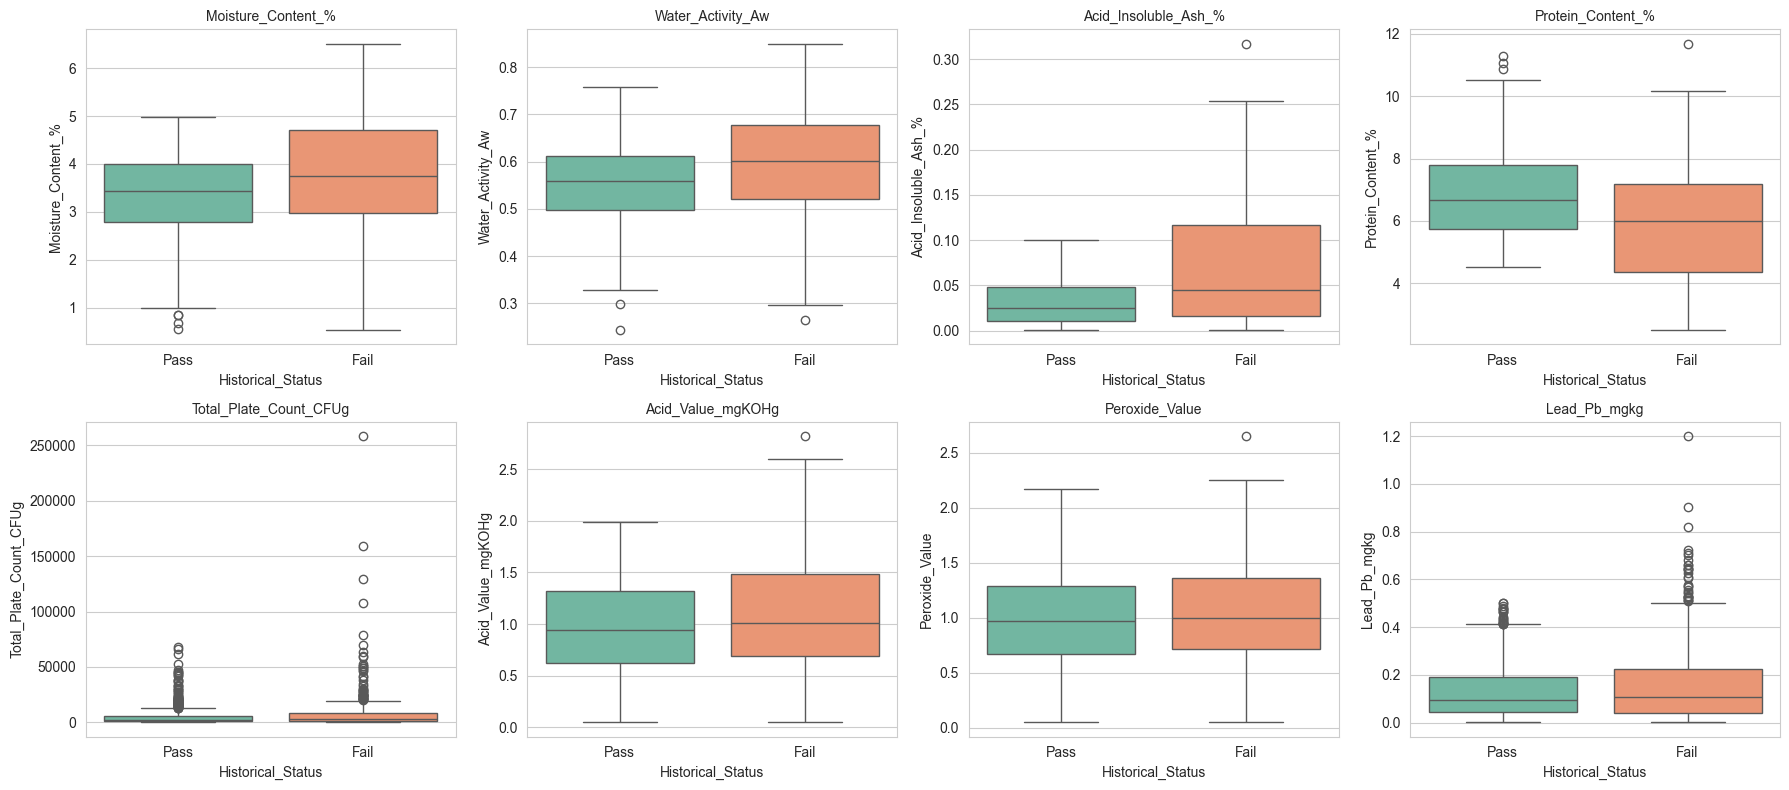

In [38]:
#visualisasi outlier

plot_cols = ['Moisture_Content_%','Water_Activity_Aw','Acid_Insoluble_Ash_%',
             'Protein_Content_%','Total_Plate_Count_CFUg','Acid_Value_mgKOHg','Peroxide_Value',
             'Lead_Pb_mgkg','Cadmium_Cd_mgkg']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(data=df, x='Historical_Status', y=col, hue='Historical_Status',
                ax=ax, palette='Set2', legend=False)
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

### 2.3 Correlation Matrix
Membuktikan secara numerik klaim di problem statement bahwa parameter lab saling
berkorelasi (moisture -> water activity -> risiko mikroba, dst).

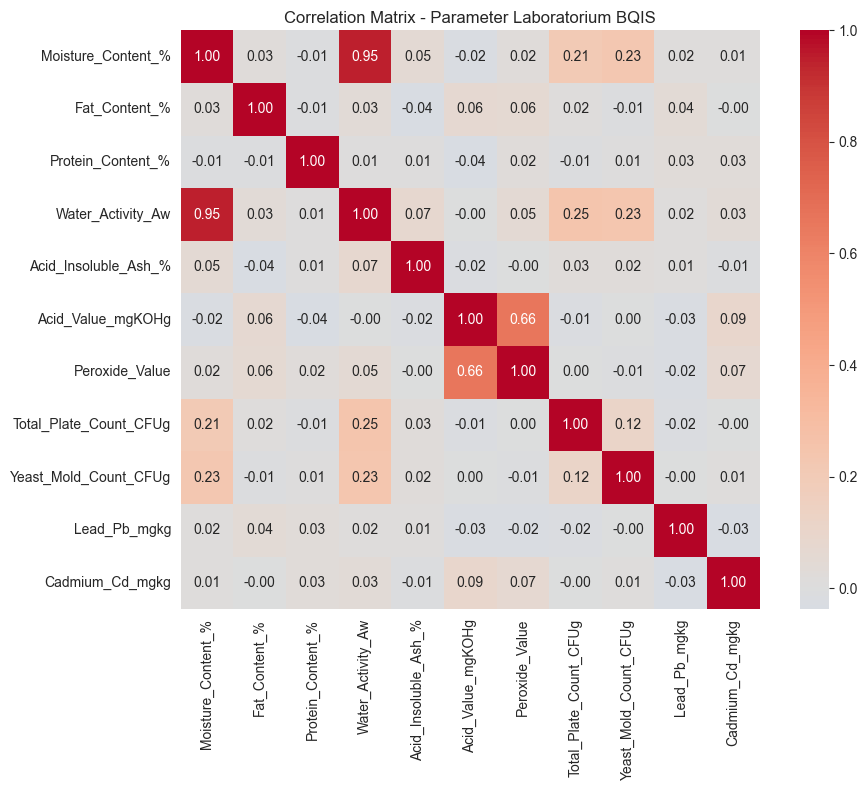

In [18]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix - Parameter Laboratorium BQIS")
plt.tight_layout()
plt.show()


### 2.4 Distribusi Parameter vs Status (Pass/Fail)
Boxplot untuk lihat parameter mana yang paling jelas bedain sampel Pass vs Fail
secara visual -- ini preview sebelum SHAP nanti kasih angka pastinya.

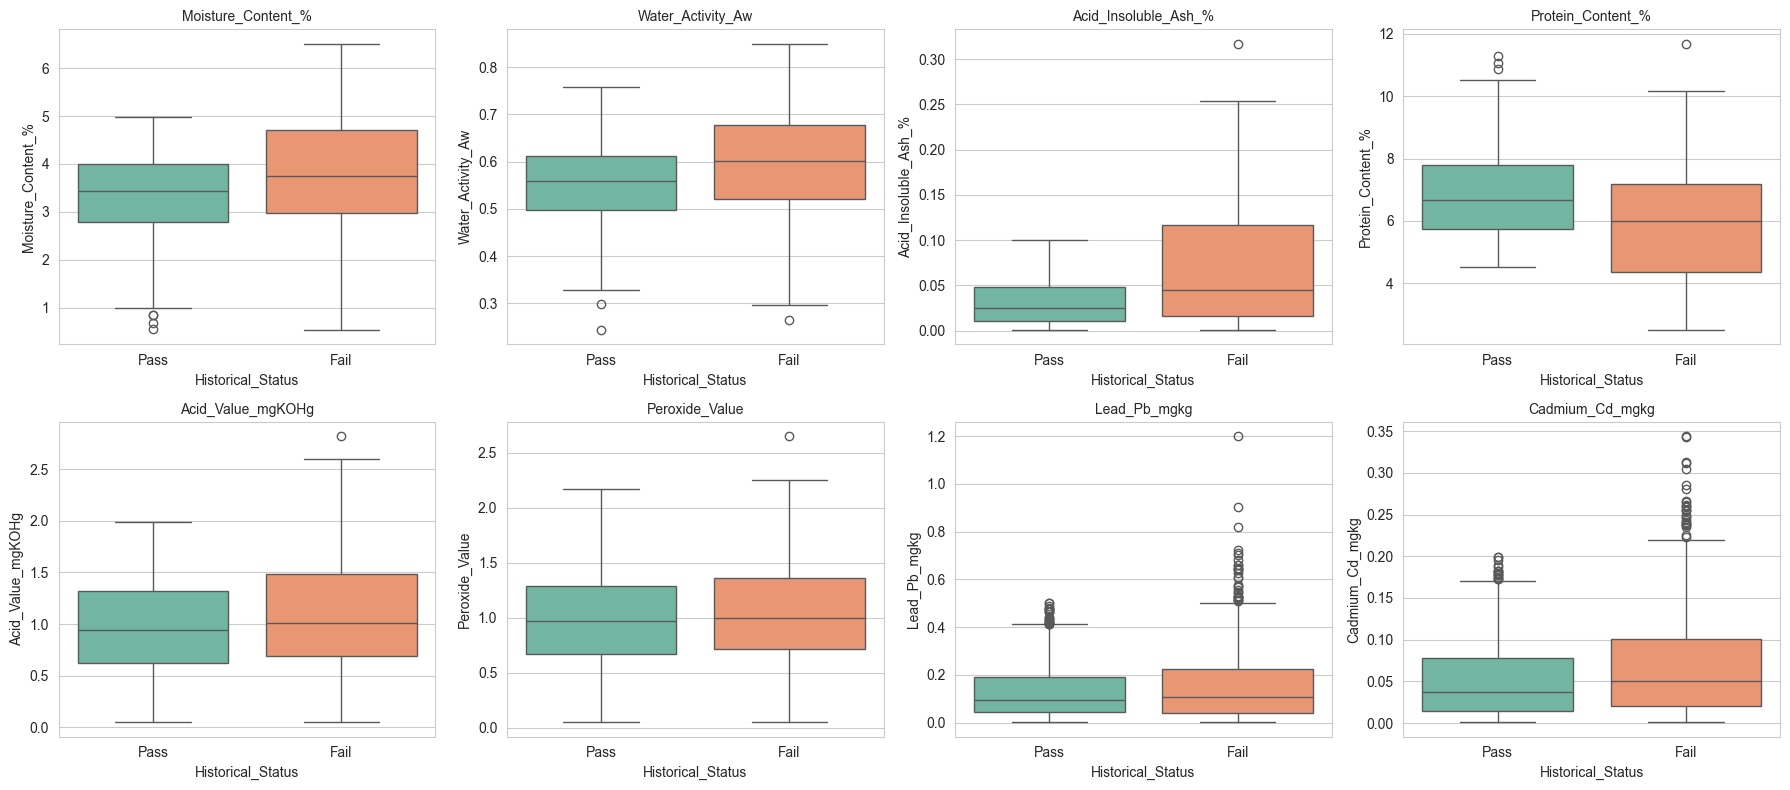

In [19]:
plot_cols = ['Moisture_Content_%','Water_Activity_Aw','Acid_Insoluble_Ash_%',
             'Protein_Content_%','Acid_Value_mgKOHg','Peroxide_Value',
             'Lead_Pb_mgkg','Cadmium_Cd_mgkg']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(data=df, x='Historical_Status', y=col, hue='Historical_Status',
                ax=ax, palette='Set2', legend=False)
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()


### 2.5 Outlier Check (Metode IQR)
Cek outlier di parameter yang secara alami skewed (misal data mikrobiologi).
Catatan: XGBoost berbasis tree, jadi relatif tidak sensitif terhadap outlier
dibanding model linear (Logistic Regression, dll).

In [20]:
for col in ['Total_Plate_Count_CFUg', 'Lead_Pb_mgkg', 'Peroxide_Value']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outlier} outlier dari {len(df)} baris ({n_outlier/len(df)*100:.1f}%)")


Total_Plate_Count_CFUg: 113 outlier dari 1000 baris (11.3%)
Lead_Pb_mgkg: 45 outlier dari 1000 baris (4.5%)
Peroxide_Value: 1 outlier dari 1000 baris (0.1%)


## 3. Preprocessing

### 3.1 Drop Kolom Leakage & Identitas

**PENTING -- Data Leakage Check:**
`Failure_Category` HARUS di-drop dari fitur classifier Pass/Fail, karena kolom ini
cuma keisi kalau sampelnya Fail (bocorin jawaban). Kolom ini disimpan terpisah,
nanti dipakai untuk validasi hasil clustering (bukan untuk training classifier).

`Sample_ID`, `Batch_Code`, `Test_Date` di-drop karena itu identitas administratif,
bukan parameter kualitas produk.

In [21]:
leak_and_id_cols = ['Sample_ID', 'Batch_Code', 'Test_Date', 'Failure_Category']
failure_category_ref = df['Failure_Category'].copy()  # disimpan, dipakai nanti di tahap clustering

df_model = df.drop(columns=leak_and_id_cols)
print("Kolom yang dipakai untuk modeling:")
print(df_model.columns.tolist())


Kolom yang dipakai untuk modeling:
['Product_Name', 'Moisture_Content_%', 'Fat_Content_%', 'Protein_Content_%', 'Water_Activity_Aw', 'Acid_Insoluble_Ash_%', 'Acid_Value_mgKOHg', 'Peroxide_Value', 'Total_Plate_Count_CFUg', 'Yeast_Mold_Count_CFUg', 'Lead_Pb_mgkg', 'Cadmium_Cd_mgkg', 'Historical_Status']


### 3.2 Encoding
- `Product_Name`: variabel nominal (tidak ada urutan) -> one-hot encoding
- `Historical_Status`: target -> mapping manual **Pass = 0, Fail = 1**
  (Fail dijadikan positive class karena itu yang paling relevan dideteksi auditor)

In [22]:
df_model = pd.get_dummies(df_model, columns=['Product_Name'], prefix='Product')
df_model['Historical_Status'] = df_model['Historical_Status'].map({'Pass': 0, 'Fail': 1})
df_model.head()


,Moisture_Content_%,Fat_Content_%,Protein_Content_%,Water_Activity_Aw,Acid_Insoluble_Ash_%,Acid_Value_mgKOHg,Peroxide_Value,Total_Plate_Count_CFUg,Yeast_Mold_Count_CFUg,Lead_Pb_mgkg,Cadmium_Cd_mgkg,Historical_Status,Product_Butter Biscuit,Product_Cookies Choco Chip,Product_Cracker Filled,Product_Cracker Plain,Product_Marie Biscuit,Product_Sandwich Biscuit,Product_Wafer Vanilla
0,3.23,19.10,9.95,0.543,0.058,1.61,1.34,5670,2232,0.045,0.098,0,False,False,False,False,False,False,True
1,1.23,17.81,4.76,0.375,0.045,1.13,1.05,5847,272,0.014,0.018,0,False,False,False,False,False,False,True
2,3.69,16.93,NaN,0.620,0.058,0.68,1.07,27579,162,0.363,0.162,0,False,True,False,False,False,False,False
3,2.69,11.10,7.07,0.505,0.071,1.69,1.27,1447,99,0.015,0.001,0,False,False,False,True,False,False,False
4,3.69,26.64,7.41,0.557,0.015,1.89,1.80,780,1397,0.509,0.039,1,False,False,True,False,False,False,False


### 3.3 KNN Imputation

Logika: untuk tiap baris yang punya missing value, cari k=5 baris "tetangga"
paling mirip (berdasarkan parameter lain yang lengkap), lalu isi nilai kosong
dengan rata-rata tertimbang jarak dari tetangga tersebut. Ini lebih akurat
dibanding isi pakai mean/median polos, karena mempertimbangkan kemiripan
multi-parameter antar sampel.

In [23]:
numeric_missing_cols = ['Moisture_Content_%','Fat_Content_%','Protein_Content_%',
                         'Water_Activity_Aw','Acid_Insoluble_Ash_%','Acid_Value_mgKOHg',
                         'Peroxide_Value','Lead_Pb_mgkg','Cadmium_Cd_mgkg']

print("Missing value SEBELUM imputation:")
print(df_model[numeric_missing_cols].isna().sum())

imputer = KNNImputer(n_neighbors=5, weights='distance')
df_model[numeric_missing_cols] = imputer.fit_transform(df_model[numeric_missing_cols])

print("\nMissing value SESUDAH imputation:")
print(df_model[numeric_missing_cols].isna().sum())


Missing value SEBELUM imputation:
Moisture_Content_%      40
Fat_Content_%           50
Protein_Content_%       50
Water_Activity_Aw       60
Acid_Insoluble_Ash_%    70
Acid_Value_mgKOHg       60
Peroxide_Value          80
Lead_Pb_mgkg            30
Cadmium_Cd_mgkg         30
dtype: int64

Missing value SESUDAH imputation:
Moisture_Content_%      0
Fat_Content_%           0
Protein_Content_%       0
Water_Activity_Aw       0
Acid_Insoluble_Ash_%    0
Acid_Value_mgKOHg       0
Peroxide_Value          0
Lead_Pb_mgkg            0
Cadmium_Cd_mgkg         0
dtype: int64


In [24]:
df_model.to_csv("bqis_preprocessed.csv", index=False)
df_model.shape


(1000, 19)

## 4. Train-Test Split

80% data untuk training, 20% untuk testing. Pakai `stratify=y` supaya proporsi
Pass:Fail di data train dan test sama-sama merepresentasikan populasi asli
(65:35) -- penting untuk data yang imbalance walau ringan.

In [25]:
X = df_model.drop(columns=['Historical_Status'])
y = df_model['Historical_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Distribusi y_train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Distribusi y_test :", y_test.value_counts(normalize=True).round(3).to_dict())


Train shape: (800, 18) | Test shape: (200, 18)
Distribusi y_train: {0: 0.652, 1: 0.348}
Distribusi y_test : {0: 0.65, 1: 0.35}


## 5. Model Training (XGBoost Classifier)

XGBoost dipilih karena: (1) tahan terhadap outlier & data skewed (relevan untuk
data mikrobiologi), (2) bisa handle interaksi non-linear antar parameter yang
saling berkorelasi, (3) punya feature importance built-in yang nanti diperdalam
pakai SHAP.

In [26]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


## 6. Evaluation Metrics

Metrik yang dipakai dan kenapa:
- **Accuracy**: gambaran umum, tapi tidak cukup sendirian karena data imbalance
- **Precision (Fail)**: dari semua yang diprediksi Fail, berapa persen yang benar-benar Fail -> penting supaya auditor tidak salah tuduh batch bagus sebagai gagal
- **Recall (Fail)**: dari semua yang benar-benar Fail, berapa persen yang berhasil terdeteksi -> ini KRITIS, karena melewatkan batch gagal (false negative) risikonya jauh lebih besar daripada false alarm
- **F1-Score**: keseimbangan precision & recall
- **ROC-AUC**: seberapa baik model membedakan Pass vs Fail di semua threshold

In [27]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 4))


Accuracy : 0.985
Precision: 1.0
Recall   : 0.9571
F1-Score : 0.9781
ROC-AUC  : 0.9855


### 6.1 Confusion Matrix

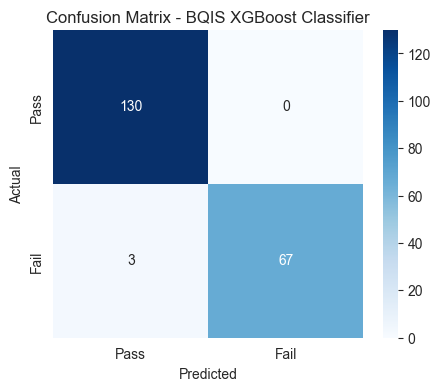

[[130   0]
 [  3  67]]


In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pass','Fail'], yticklabels=['Pass','Fail'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BQIS XGBoost Classifier")
plt.show()

print(cm)


### 6.2 Classification Report

In [29]:
print(classification_report(y_test, y_pred, target_names=['Pass','Fail']))


              precision    recall  f1-score   support

        Pass       0.98      1.00      0.99       130
        Fail       1.00      0.96      0.98        70

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



### 6.3 ROC Curve

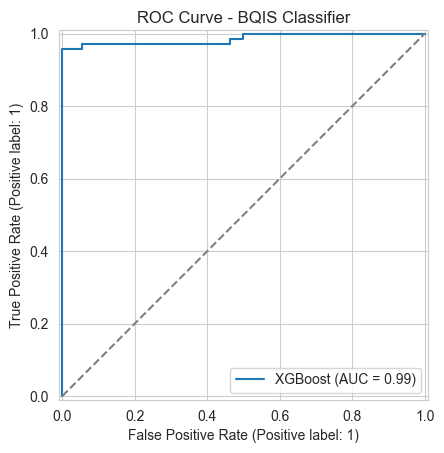

In [30]:
RocCurveDisplay.from_predictions(y_test, y_proba, name='XGBoost')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("ROC Curve - BQIS Classifier")
plt.show()


### 6.4 Feature Importance (preview sebelum SHAP)

Ini baru feature importance bawaan XGBoost (global, berdasarkan frekuensi split).
Untuk penjelasan per-sample yang lebih presisi dan sesuai klaim Explainable AI di
proposal, lanjut ke tahap SHAP (notebook terpisah).

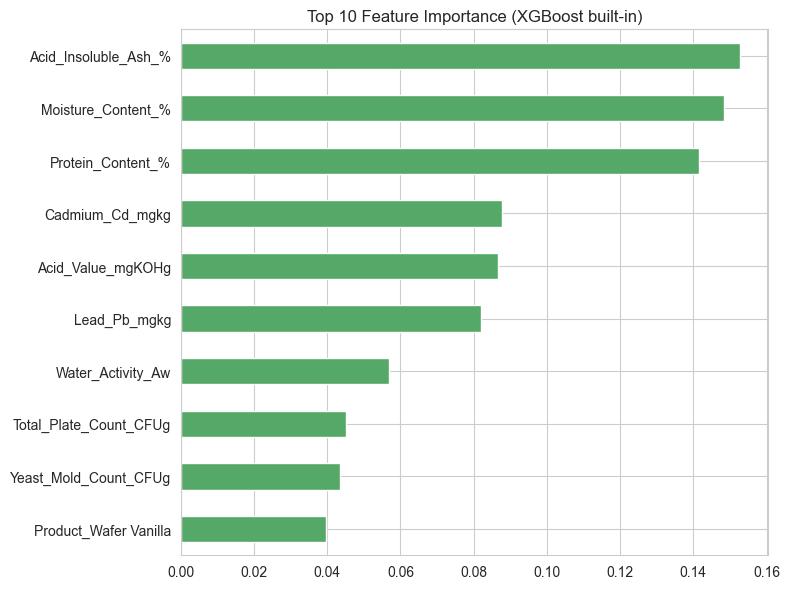

Acid_Insoluble_Ash_%      0.152728
Moisture_Content_%        0.148267
Protein_Content_%         0.141444
Cadmium_Cd_mgkg           0.087839
Acid_Value_mgKOHg         0.086655
Lead_Pb_mgkg              0.082031
Water_Activity_Aw         0.056725
Total_Plate_Count_CFUg    0.045202
Yeast_Mold_Count_CFUg     0.043595
Product_Wafer Vanilla     0.039749
dtype: float32

In [31]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind='barh', color='#55A868')
plt.title("Top 10 Feature Importance (XGBoost built-in)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importance.head(10)


## Next Steps

1. **SHAP Analysis** -- penjelasan per-sample, kenapa satu batch spesifik diprediksi Fail
2. **Clustering (K-Means / DBSCAN)** -- pakai `failure_category_ref` yang disimpan tadi untuk validasi apakah cluster yang ditemukan align sama kategori kegagalan asli
3. **Dashboard** -- bungkus semua ini jadi Streamlit app untuk demo video


---
## 7. SHAP Analysis (Explainable AI)

Tujuan: menjelaskan **kenapa** model memprediksi suatu sampel Pass/Fail, baik
secara global (pola dari banyak sampel sekaligus) maupun local (per satu sampel
spesifik). Karena model yang dipakai berbasis tree (XGBoost), SHAP otomatis
memakai **TreeExplainer** yang menghitung exact Shapley value secara efisien.

In [32]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("Shape SHAP values:", shap_values.shape)
print("Shape X_test      :", X_test.shape)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape SHAP values: (200, 18)
Shape X_test      : (200, 18)


### 7.1 Global Explanation — Summary Plot (Beeswarm)

Ini yang menjawab pertanyaan "dari BANYAK sampel Pass dan Fail sekaligus,
parameter apa yang paling menentukan?". Setiap titik mewakili satu sampel di
test set (200 sampel: campuran Pass & Fail). Warna merah = nilai parameter
tinggi, biru = nilai parameter rendah. Posisi kanan = mendorong ke Fail,
posisi kiri = mendorong ke Pass.

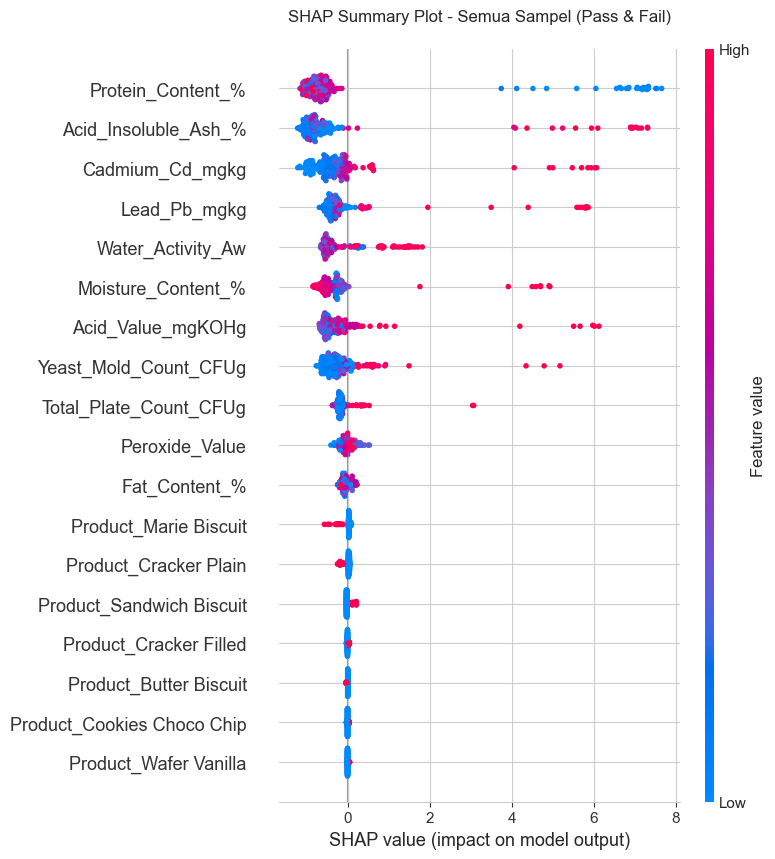

In [33]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot - Semua Sampel (Pass & Fail)", pad=20)
plt.tight_layout()
plt.show()


### 7.2 Global Explanation — Mean Absolute SHAP (Bar Chart)

Versi ringkas dari summary plot: rata-rata besarnya pengaruh tiap parameter
tanpa memandang arah (Pass/Fail). Cocok ditaruh di dashboard sebagai
"Parameter Importance Ranking" untuk auditor.

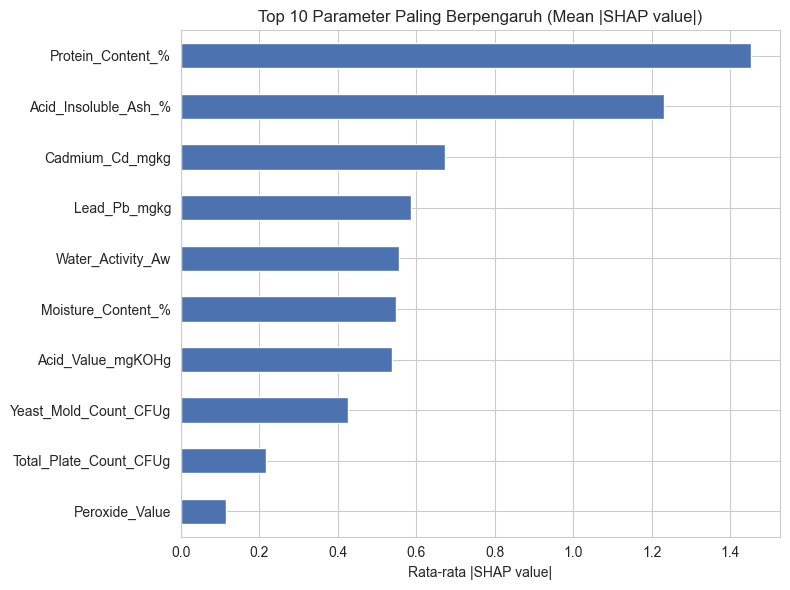

Protein_Content_%         1.453421
Acid_Insoluble_Ash_%      1.229543
Cadmium_Cd_mgkg           0.671930
Lead_Pb_mgkg              0.587371
Water_Activity_Aw         0.556580
Moisture_Content_%        0.548467
Acid_Value_mgKOHg         0.538198
Yeast_Mold_Count_CFUg     0.425811
Total_Plate_Count_CFUg    0.218017
Peroxide_Value            0.115037
dtype: float32

In [34]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_test.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
mean_abs_shap.head(10).plot(kind='barh', color='#4C72B0')
plt.title("Top 10 Parameter Paling Berpengaruh (Mean |SHAP value|)")
plt.xlabel("Rata-rata |SHAP value|")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

mean_abs_shap.head(10)


### 7.3 Local Explanation — Satu Sampel Fail

Menjawab "kenapa sampel SPESIFIK ini diprediksi Fail?". Waterfall plot
menunjukkan parameter mana yang mendorong prediksi dari base value (rata-rata
prediksi seluruh data) ke arah nilai prediksi akhir sampel ini.

Sampel index (posisi di X_test): 4
Actual label : Fail
Predicted    : Fail
Predicted probability (Fail): 0.987


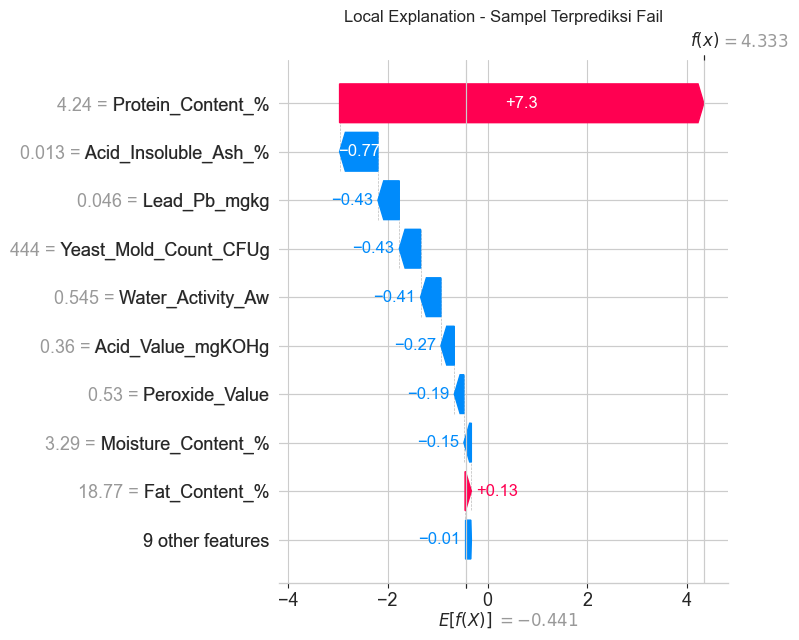

In [35]:
# Ambil index sampel Fail pertama di test set (prediksi model = 1)
fail_idx = np.where(y_pred == 1)[0][0]

print("Sampel index (posisi di X_test):", fail_idx)
print("Actual label :", 'Fail' if y_test.iloc[fail_idx] == 1 else 'Pass')
print("Predicted    :", 'Fail' if y_pred[fail_idx] == 1 else 'Pass')
print("Predicted probability (Fail):", round(y_proba[fail_idx], 4))

explanation = shap.Explanation(
    values=shap_values[fail_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[fail_idx],
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(explanation, show=False)
plt.title("Local Explanation - Sampel Terprediksi Fail")
plt.tight_layout()
plt.show()


### 7.4 Local Explanation — Satu Sampel Pass (Pembanding)

Dibandingkan dengan sampel Fail di atas, supaya terlihat kontras: parameter apa
yang membuat sampel ini justru dianggap aman.

Sampel index (posisi di X_test): 0
Actual label : Pass
Predicted    : Pass
Predicted probability (Fail): 0.0092


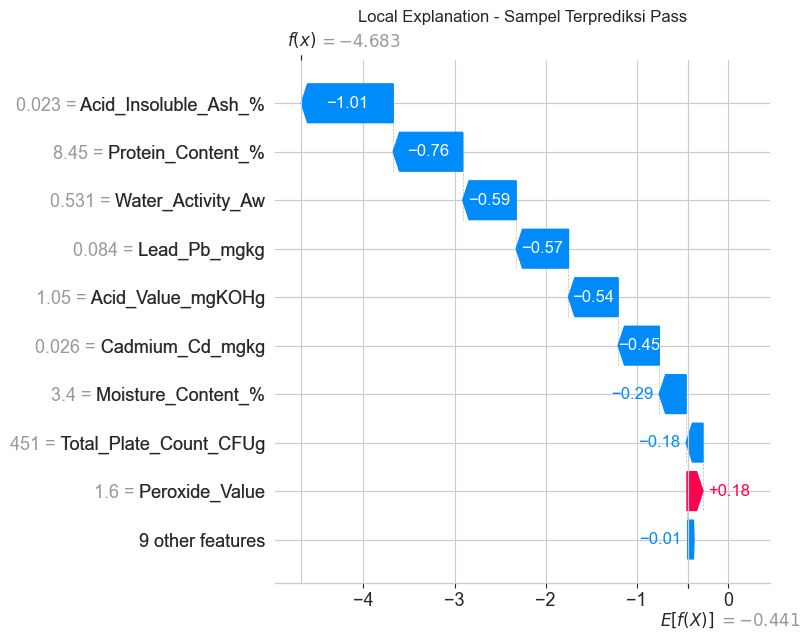

In [36]:
pass_idx = np.where(y_pred == 0)[0][0]

print("Sampel index (posisi di X_test):", pass_idx)
print("Actual label :", 'Fail' if y_test.iloc[pass_idx] == 1 else 'Pass')
print("Predicted    :", 'Fail' if y_pred[pass_idx] == 1 else 'Pass')
print("Predicted probability (Fail):", round(y_proba[pass_idx], 4))

explanation_pass = shap.Explanation(
    values=shap_values[pass_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[pass_idx],
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(explanation_pass, show=False)
plt.title("Local Explanation - Sampel Terprediksi Pass")
plt.tight_layout()
plt.show()


### 7.5 Dependence Plot — Interaksi Antar Parameter

Menunjukkan hubungan antara nilai satu parameter (sumbu X) dengan pengaruhnya
terhadap prediksi (sumbu Y = SHAP value), sekaligus diwarnai oleh parameter
kedua yang paling berinteraksi dengannya. Berguna untuk melihat threshold —
misal di titik nilai berapa suatu parameter mulai konsisten mendorong ke Fail.

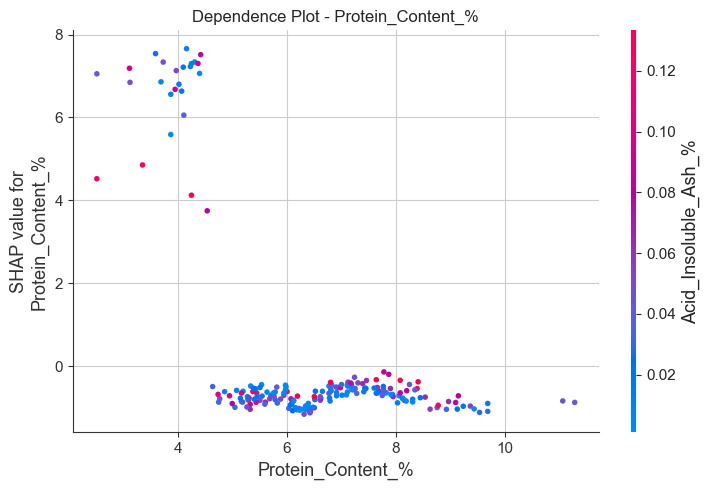

In [37]:
top_feature = mean_abs_shap.index[0]

shap.dependence_plot(top_feature, shap_values, X_test, show=False)
plt.title(f"Dependence Plot - {top_feature}")
plt.tight_layout()
plt.show()


## Ringkasan Section 7

- **Summary plot & bar chart** -> jawaban untuk "insight dari banyak sampel Pass+Fail sekaligus", cocok untuk Dashboard "Parameter Importance Ranking"
- **Waterfall plot per sampel** -> jawaban untuk "kenapa batch spesifik ini gagal", cocok untuk fitur drill-down di Audit Intelligence Dashboard
- **Dependence plot** -> insight tambahan soal threshold/interaksi antar parameter, bisa dipakai memperkuat argumen di Executive Summary

**Next:** Clustering (K-Means/DBSCAN) untuk failure pattern discovery, divalidasi dengan `failure_category_ref`.
